In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Run this cell first — installs and imports everything you need
# If something fails, read the error carefully before asking for help!

!pip install torch numpy matplotlib seaborn -q

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"Device available: {'GPU ' if torch.cuda.is_available() else 'CPU '}")

All imports successful!
PyTorch version: 2.10.0+cpu
Device available: CPU 


In [3]:
# Verify your manual calculation here
import numpy as np

W_x = 0.8
W_h = 0.5
b   = 0.1
h0  = 0.0
x1  = 1.0
x2  = 0.5

# YOUR CODE HERE
# Calculate h1
h1 = np.tanh(W_h * h0 + W_x * x1 + b)

# Calculate h2
h2 = np.tanh(W_h * h1 + W_x * x2 + b)

print(f"h1 = {h1}")
print(f"h2 = {h2}")

h1 = 0.7162978701990245
h2 = 0.695302727644787


In [4]:
# ── DEMO: Basic RNN in PyTorch ──────────────────────────────────────────
# Run this cell to see how nn.RNN works. Read the output carefully.

rnn = nn.RNN(input_size=5, hidden_size=8, num_layers=1, batch_first=True)

# Fake input: batch_size=2, sequence_length=6, input_size=5
x  = torch.randn(2, 6, 5)
h0 = torch.zeros(1, 2, 8)   # (num_layers, batch_size, hidden_size)

output, h_n = rnn(x, h0)

print("Input shape:         ", x.shape)
print("Initial hidden shape:", h0.shape)
print("Output shape:        ", output.shape, "  ← hidden state at every time step")
print("Final hidden shape:  ", h_n.shape,   "  ← hidden state at last time step only")
print()
print("output[:, -1, :] == h_n[0]:", torch.allclose(output[:, -1, :], h_n[0]))

Input shape:          torch.Size([2, 6, 5])
Initial hidden shape: torch.Size([1, 2, 8])
Output shape:         torch.Size([2, 6, 8])   ← hidden state at every time step
Final hidden shape:   torch.Size([1, 2, 8])   ← hidden state at last time step only

output[:, -1, :] == h_n[0]: True


In [5]:
# ── EXERCISE 3.1: Build a Simple RNN Classifier ──────────────────────────
#
# Task: Build a class called SimpleRNNClassifier that:
#   - Takes sequences of input_size=10
#   - Has a hidden_size of 16
#   - Has a fully connected layer that maps hidden state → 2 classes
#   - Uses the FINAL hidden state (h_n) to make the classification
#
# This is a Many-to-One architecture (whole sequence → one label)

import torch
import torch.nn as nn

class SimpleRNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleRNNClassifier, self).__init__()

        # RNN layer
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)

        # Fully connected layer
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)

        batch_size = x.size(0)

        # Initialize hidden state with zeros
        h0 = torch.zeros(1, batch_size, self.rnn.hidden_size)

        # Pass through RNN
        out, h_n = self.rnn(x, h0)

        # h_n shape: (num_layers, batch_size, hidden_size)
        # Take final hidden state
        final_hidden = h_n[-1]

        # Pass through fully connected layer
        out = self.fc(final_hidden)

        return out

In [6]:
# Testing my model
model = SimpleRNNClassifier(10, 16, 2)
test_input = torch.randn(4, 7, 10)

output = model(test_input)
print(f"Output shape is: {output.shape}")

Output shape is: torch.Size([4, 2])


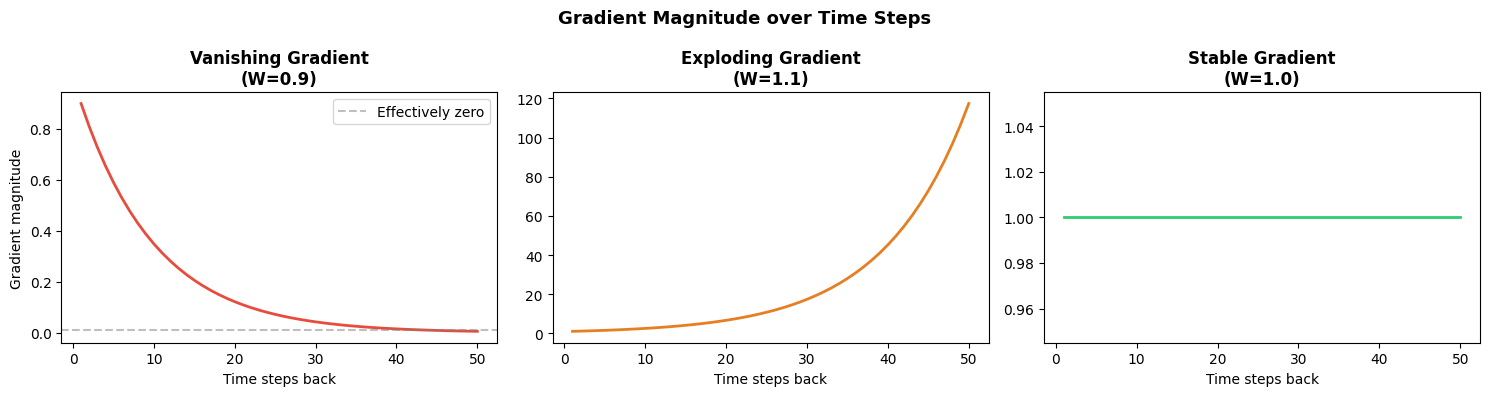

In [7]:
# DEMO: Visualize how gradients vanish over time steps

steps = np.arange(1, 51)

w_vanish  = 0.9  # |W| < 1 → gradients shrink
w_explode = 1.1  # |W| > 1 → gradients grow
w_good    = 1.0  # |W| = 1 → gradients stable (rare in practice)

grad_vanish  = w_vanish  ** steps
grad_explode = np.clip(w_explode ** steps, 0, 1e6)  # clip for display
grad_good    = w_good    ** steps

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(steps, grad_vanish, color='#e74c3c', linewidth=2)
axes[0].set_title('Vanishing Gradient\n(W=0.9)', fontweight='bold')
axes[0].set_xlabel('Time steps back')
axes[0].set_ylabel('Gradient magnitude')
axes[0].axhline(y=0.01, color='gray', linestyle='--', alpha=0.5, label='Effectively zero')
axes[0].legend()

axes[1].plot(steps, grad_explode, color='#e67e22', linewidth=2)
axes[1].set_title('Exploding Gradient\n(W=1.1)', fontweight='bold')
axes[1].set_xlabel('Time steps back')

axes[2].plot(steps, grad_good, color='#2ecc71', linewidth=2)
axes[2].set_title('Stable Gradient\n(W=1.0)', fontweight='bold')
axes[2].set_xlabel('Time steps back')

plt.suptitle('Gradient Magnitude over Time Steps', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

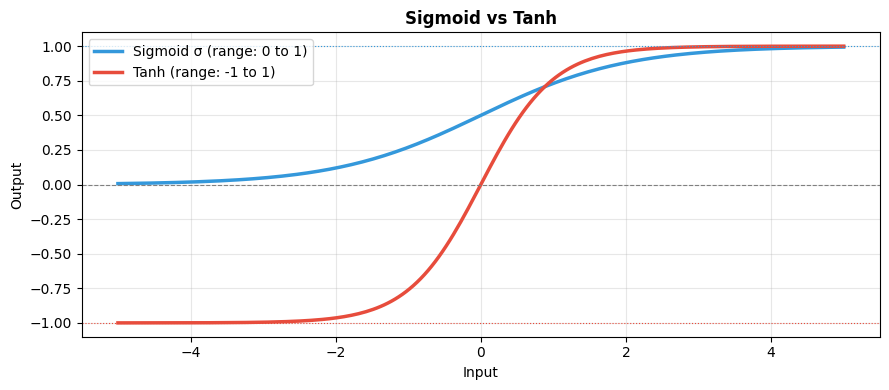

Sigmoid at 0: 0.5  → gates start at 0.5 (neutral)
Tanh    at 0: 0.0     → candidate values centered at 0


In [8]:
x = np.linspace(-5, 5, 200)
sigmoid = 1 / (1 + np.exp(-x))
tanh    = np.tanh(x)

plt.figure(figsize=(9, 4))
plt.plot(x, sigmoid, color='#3498db', linewidth=2.5, label='Sigmoid σ (range: 0 to 1)')
plt.plot(x, tanh,    color='#e74c3c', linewidth=2.5, label='Tanh (range: -1 to 1)')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.axhline(1, color='#3498db', linewidth=0.8, linestyle=':')
plt.axhline(-1, color='#e74c3c', linewidth=0.8, linestyle=':')
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Sigmoid vs Tanh', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Sigmoid at 0:", round(1/(1+np.exp(0)), 3),  " → gates start at 0.5 (neutral)")
print("Tanh    at 0:", round(np.tanh(0), 3), "    → candidate values centered at 0")
     

In [9]:
import torch
import torch.nn as nn

class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(LSTMClassifier, self).__init__()
        
        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )
        
        # Fully connected layer
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        batch_size = x.size(0)
        
        # Initialize hidden state and cell state
        h0 = torch.zeros(1, batch_size, self.lstm.hidden_size).to(x.device)
        c0 = torch.zeros(1, batch_size, self.lstm.hidden_size).to(x.device)
        
        # Forward pass through LSTM
        output, (h_n, c_n) = self.lstm(x, (h0, c0))
        
        # Take final hidden state
        final_hidden = h_n[-1]
        
        # Pass through fully connected layer
        out = self.fc(final_hidden)
        
        return out

In [10]:
# Testing the model
lstm_model = LSTMClassifier(input_size=10, hidden_size=16, num_classes=3)
test_input  = torch.randn(4, 7, 10)
output      = lstm_model(test_input)
print("Output shape:", output.shape)  # should be (4, 3)
print("✅ Correct!" if output.shape == (4, 3) else "❌ Check your code")

Output shape: torch.Size([4, 3])
✅ Correct!


In [11]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Create models
rnn_clf = SimpleRNNClassifier(input_size=10, hidden_size=32, num_classes=2)
lstm_clf = LSTMClassifier(input_size=10, hidden_size=32, num_classes=2)

# Print counts
print(f"RNN parameters: {count_parameters(rnn_clf):,}")
print(f"LSTM parameters: {count_parameters(lstm_clf):,}")
print(f"Ratio (LSTM/RNN): {count_parameters(lstm_clf)/count_parameters(rnn_clf):.2f}x")

RNN parameters: 1,474
LSTM parameters: 5,698
Ratio (LSTM/RNN): 3.87x


# **DIVING INTO GRU's**

| Feature | RNN | LSTM | GRU |
|---|---|---|---|
| Number of gates | 0 | 3 [input, output, forget] | 2 [update, reset]|
| Number of states (h, c) | 1 hidden state | Hidden + cell state | 1 hidden state |
| Handles long dependencies? | Poorly as has no gates | Yes (Better than GRUs also) | Yes |
| Relative speed | Fastest | Slowest | Faster than LSTM |
| When would you choose this? | Simple short sequences | Complex long-term dependencies and longer sequences| Faster choice than LSTM + better performance |

In [12]:
import torch
import torch.nn as nn

class GRUClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(GRUClassifier, self).__init__()

        # GRU layer
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )

        # Fully connected layer
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        batch_size = x.size(0)

        # Initialize hidden state
        h0 = torch.zeros(1, batch_size, self.gru.hidden_size).to(x.device)

        # Forward pass through GRU
        output, h_n = self.gru(x, h0)

        # Take final hidden state
        final_hidden = h_n[-1]

        # Classification
        out = self.fc(final_hidden)

        return out


In [13]:
#Testing the model
test_input = torch.randn(4, 7, 10)
gru_model = GRUClassifier(input_size=10, hidden_size=16, num_classes=3)

output = gru_model(test_input)
print("Output shape:", output.shape)
print("✅ Correct!" if output.shape == (4, 3) else "❌ Check your code")

Output shape: torch.Size([4, 3])
✅ Correct!


# **Section 7 —Character-Level Language Model** 

In [14]:
# ── STEP 1: Data Preparation ──────────────────────────────────────────────
# This cell is fully provided — read it and understand each part.

# Training text: Python function signatures (DocForge relevant!)
text = """
def calculate_area(radius):
def sort_list(items, reverse=False):
def read_file(filepath, encoding='utf-8'):
def find_max(numbers):
def merge_dicts(dict_a, dict_b):
def is_palindrome(string):
def count_words(text):
def format_output(data, indent=4):
def load_model(path, device='cpu'):
def tokenize_code(source, language='python'):
""".strip()

# Build character vocabulary
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"Text length: {len(text)} characters")
print(f"Unique characters: {vocab_size}")
print(f"Characters: {''.join(chars)}")

# Create mappings
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

# Encode entire text as integers
encoded = [char_to_idx[ch] for ch in text]
print(f"\nFirst 10 encoded: {encoded[:10]}")
print(f"Decoded back: {''.join([idx_to_char[i] for i in encoded[:10]])}")

Text length: 330 characters
Unique characters: 37
Characters: 
 '(),-48:=F_abcdefghiklmnoprstuvwxyz

First 10 encoded: [16, 17, 18, 1, 15, 13, 23, 15, 31, 23]
Decoded back: def calcul


In [15]:
# ── STEP 2: Create Training Sequences ─────────────────────────────────────
# Provided — read and understand

SEQ_LEN = 20  # length of each input sequence

def create_sequences(encoded_text, seq_len):
    """Create (input_sequence, target_sequence) pairs."""
    inputs, targets = [], []
    for i in range(len(encoded_text) - seq_len):
        inputs.append(encoded_text[i : i + seq_len])
        targets.append(encoded_text[i + 1 : i + seq_len + 1])  # shifted by 1
    return torch.tensor(inputs, dtype=torch.long), torch.tensor(targets, dtype=torch.long)

X, y = create_sequences(encoded, SEQ_LEN)
print(f"Input sequences shape:  {X.shape}")
print(f"Target sequences shape: {y.shape}")
print(f"\nExample:")
print(f"  Input:  {''.join([idx_to_char[i.item()] for i in X[0]])}")
print(f"  Target: {''.join([idx_to_char[i.item()] for i in y[0]])}")

Input sequences shape:  torch.Size([310, 20])
Target sequences shape: torch.Size([310, 20])

Example:
  Input:  def calculate_area(r
  Target: ef calculate_area(ra


In [18]:
import torch
import torch.nn as nn

class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers):
        super(CharLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # 🔹 1. Embedding layer (char index → vector)
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # 🔹 2. LSTM layer
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        # 🔹 3. Fully connected layer (hidden → vocab)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        # x shape: (batch_size, seq_len)

        # 🔹 Step 1: Embedding
        x = self.embedding(x)  
        # (batch, seq_len, embed_dim)

        # 🔹 Step 2: LSTM
        out, _ = self.lstm(x)  
        # (batch, seq_len, hidden_size)

        # 🔹 Step 3: Linear layer
        out = self.fc(out)  
        # (batch, seq_len, vocab_size)

        return out



In [19]:
# Here i have Instantiated:
EMBED_DIM   = 32
HIDDEN_SIZE = 128
NUM_LAYERS  = 2

char_model = CharLSTM(vocab_size, EMBED_DIM, HIDDEN_SIZE, NUM_LAYERS)

print(f"Model parameters: {count_parameters(char_model):,}")

# Quick shape check
test_out = char_model(X[:4])
print(f"Output shape: {test_out.shape}")  # should be (4, SEQ_LEN, vocab_size)
print("✅ Correct!" if test_out.shape == (4, SEQ_LEN, vocab_size) else "❌ Check your code")

Model parameters: 220,997
Output shape: torch.Size([4, 20, 37])
✅ Correct!


Epoch [ 10/80]  Loss: 0.2340
Epoch [ 20/80]  Loss: 0.1541
Epoch [ 30/80]  Loss: 0.1407
Epoch [ 40/80]  Loss: 0.1379
Epoch [ 50/80]  Loss: 0.1367
Epoch [ 60/80]  Loss: 0.1356
Epoch [ 70/80]  Loss: 0.1344
Epoch [ 80/80]  Loss: 0.1331


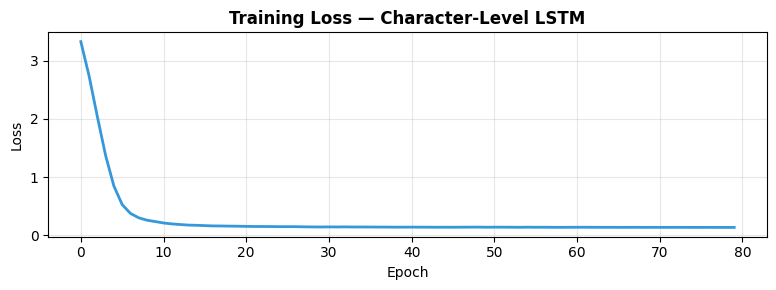

In [20]:
# ── STEP 4: Training Loop ─────────────────────────────────────────────────
# Provided — read and understand, then run.

from torch.utils.data import DataLoader, TensorDataset

EPOCHS     = 80
BATCH_SIZE = 32
LR         = 0.005

dataset    = TensorDataset(X, y)
loader     = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(char_model.parameters(), lr=LR)

loss_history = []

for epoch in range(EPOCHS):
    char_model.train()
    total_loss = 0
    for xb, yb in loader:
        optimizer.zero_grad()
        logits = char_model(xb)            # (batch, seq_len, vocab_size)
        # Reshape for CrossEntropyLoss: (batch*seq_len, vocab_size) vs (batch*seq_len,)
        loss   = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(char_model.parameters(), 1.0)  # gradient clipping!
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    loss_history.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:3d}/{EPOCHS}]  Loss: {avg_loss:.4f}")

# Plot training curve
plt.figure(figsize=(8, 3))
plt.plot(loss_history, color='#3498db', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss — Character-Level LSTM', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# ── STEP 5: Generate Text ──────────────────────────────────────────────────
# Provided — run after training

def generate_text(model, seed_text, length=80, temperature=0.8):
    """
    Generate text starting from seed_text.
    temperature: lower = more deterministic, higher = more random
    """
    model.eval()
    result = list(seed_text)
    input_seq = [char_to_idx.get(ch, 0) for ch in seed_text[-SEQ_LEN:]]

    with torch.no_grad():
        for _ in range(length):
            x_in  = torch.tensor([input_seq[-SEQ_LEN:]], dtype=torch.long)
            logits = model(x_in)[0, -1, :]  # last time step
            probs  = torch.softmax(logits / temperature, dim=0).numpy()
            next_idx = np.random.choice(len(probs), p=probs)
            result.append(idx_to_char[next_idx])
            input_seq.append(next_idx)

    return ''.join(result)

print("Generated text (seed='def '):")
print("-" * 50)
print(generate_text(char_model, "def ", length=100))
print("-" * 50)
print("\nGenerated text (seed='def load'):")
print("-" * 50)
print(generate_text(char_model, "def load", length=80))

Generated text (seed='def '):
--------------------------------------------------
def format_output(data, indent=4):
def load_model(path, device='cpu'):
def tokenize_code(source, languag
--------------------------------------------------

Generated text (seed='def load'):
--------------------------------------------------
def load_model(path, device='cpu'):
def tokenize_code(source, language='python'):
def to


Q1) Look at the generated text. Does it look Python-like? What patterns did the model learn?
* Yes the final generated text does look Python-like. The model learned common Python syntax like it started the text with def which is used to start off functions in oops. It learnt how to format and used ; : with good accuracy

Q2) In the training loop, there's a line: torch.nn.utils.clip_grad_norm_(char_model.parameters(), 1.0). What does this do and why is it there?
* This is used for something called 'gradient clipping'. This basically limits the size of the gradient descent and prevent overflow/ exploding of data.

Q3) What does the temperature parameter control in text generation? What happens if you set it to 0.1 vs 2.0? (Try it!)
* This parameter controls the randomness of text generation. 0.1 makes the words more repetive 1 is balanced and 2 increased the randomness. This 2 could also increse errors due to more variable data.

Q4) This model was only trained on 10 function signatures. If we trained it on thousands of Python functions (like the Code2Doc dataset used in DocForge), what do you think would improve?
* More the functions more the model will learn and improve thus better would be the performance. The newly generated code would become even more python like with it being more realistic

# REFLECTION****

Q1) In the DocForge project, Phase 5 covers Transformer models (CodeT5, CodeBERT). Now that you understand RNNs and LSTMs, what do you think Transformers might do differently to handle sequences? What limitation of LSTMs might they fix?

* LSTMs are better than  RNNs but still have a major problem of difficulty in capturing long-range dependencies. This makes the model slower ans probably increases training time. These are all sequential models, so we have to process data one by one. Transformers would probably have a better mechanism to handle the input data and focus on more relevant parts.


Q2) What part of this worksheet was most confusing? What would you look up or experiment with more before moving to Transformers?

* For me personally, understanding backtracking in rnn wqs first a little challenging. This is because now there is a time-dependent factor as well and calculating the partial derivatives for longer sequences i found to  be a little challenging. Understanding LSTMs gates and how they maneuver long-term dependencies was also slightly challenging and i would like to explore it more in the summer


Q3) If you had to use an LSTM to help with one specific part of the DocForge pipeline (parsing code, generating docstrings, evaluating output quality), which would you pick and how would you set it up?

* I would probably use LSTMs to generate docstrings as it would help generate meaningful test putput in a simpler way. I would do this by-
  - Tokenize input sequences
  - Train the model using LSTMs and its gates to generate text and explain what exactly it is that the function does.
  - Use embedding as to use less sparse data filled with 0s and get more dense meaningful data after vectorizing the input
  - As it is a multiclass classification, use softmax to geneate output (Loss func being Cross entropy)
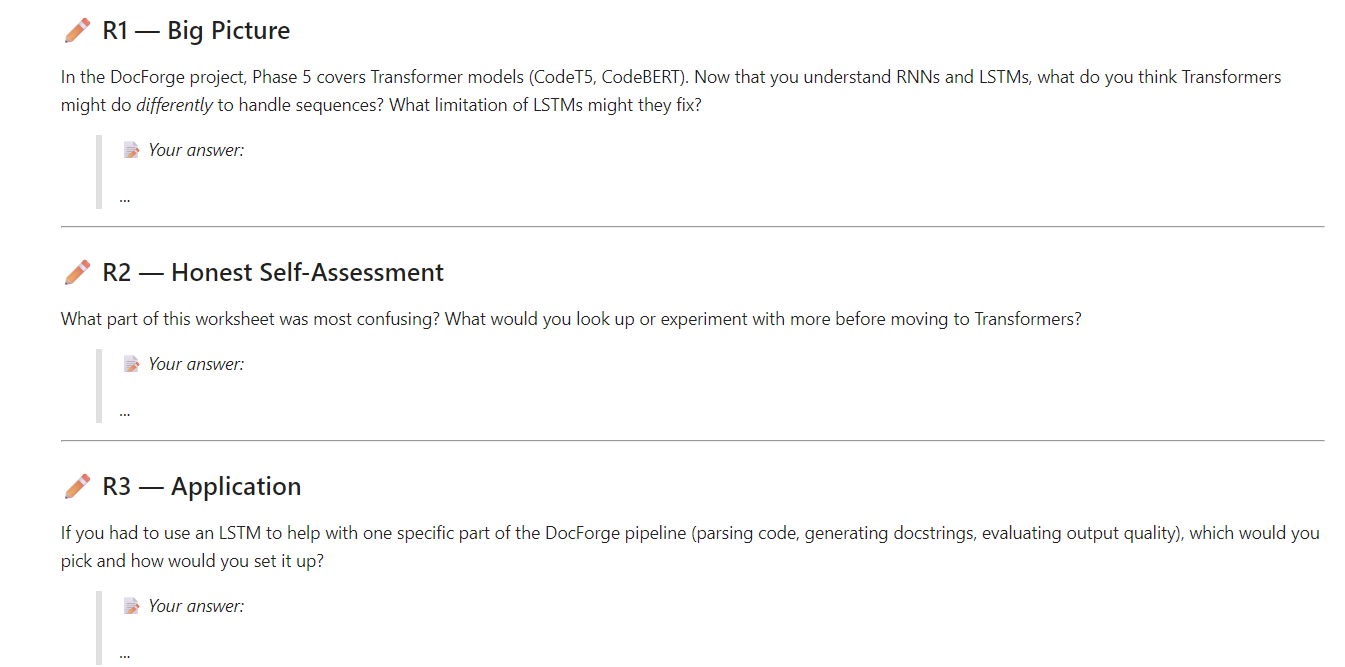